**Problem Statement:** <br>
Implementation of RNN model for Stock Price Prediction.

# Install and import libraries

In [ ]:
!pip install yfinance

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout

# Load dataset

In [ ]:
df = yf.download("AAPL", start="2015-01-01", end="2024-01-01")

data = df[['Close']]

/tmp/ipykernel_2675/1513296246.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download("AAPL", start="2015-01-01", end="2024-01-01")
[*********************100%***********************]  1 of 1 completed


# Preprocessing

In [ ]:
scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(data)

# Create sequences (window size = 60 days)

In [ ]:
X = []
y = []

for i in range(60, len(scaled_data)):
    X.append(scaled_data[i-60:i, 0])
    y.append(scaled_data[i, 0])

X, y = np.array(X), np.array(y)

# Reshape for RNN [samples, timesteps, features]

In [ ]:
X = np.reshape(X, (X.shape[0], X.shape[1], 1))

# Train-Test Split

In [ ]:
split = int(0.8 * len(X))

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# Build RNN (LSTM Model)

In [ ]:
model = Sequential()

model.add(LSTM(units=50, return_sequences=True, input_shape=(X.shape[1],1)))
model.add(Dropout(0.2))

model.add(LSTM(units=50, return_sequences=True))
model.add(Dropout(0.2))

model.add(LSTM(units=50))
model.add(Dropout(0.2))

model.add(Dense(units=1))

model.compile(optimizer='adam', loss='mean_squared_error')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


# Train model

In [ ]:
model.fit(X_train, y_train, epochs=10, batch_size=32)

Epoch 1/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 17s 129ms/step - loss: 0.0111
Epoch 2/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 7s 75ms/step - loss: 0.0020
Epoch 3/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 6s 100ms/step - loss: 0.0019
Epoch 4/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 4s 75ms/step - loss: 0.0015
Epoch 5/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 4s 75ms/step - loss: 0.0015
Epoch 6/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 6s 100ms/step - loss: 0.0015
Epoch 7/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 4s 76ms/step - loss: 0.0019
Epoch 8/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 5s 76ms/step - loss: 0.0015
Epoch 9/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 6s 87ms/step - loss: 0.0015
Epoch 10/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 4s 75ms/step - loss: 0.0013


# Predictions

In [ ]:
predictions = model.predict(X_test)
predictions = scaler.inverse_transform(predictions.reshape(-1,1))

# Convert y_test back
y_test_actual = scaler.inverse_transform(y_test.reshape(-1,1))

14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step


# Plot results

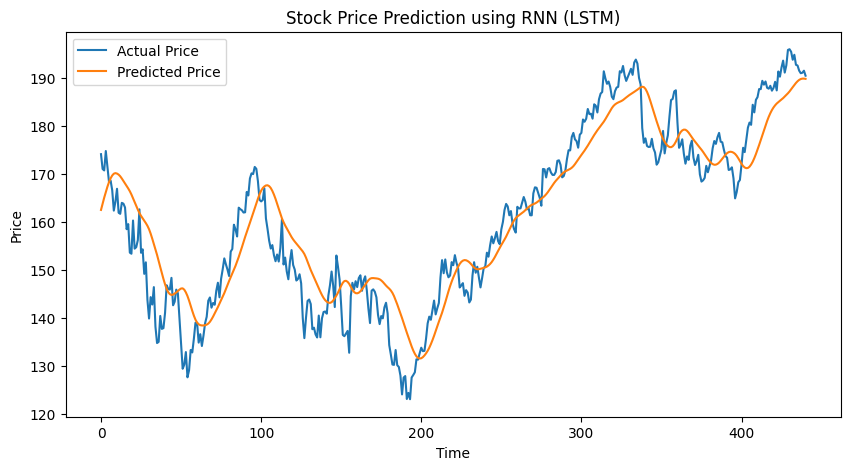

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(y_test_actual, label="Actual Price")
plt.plot(predictions, label="Predicted Price")
plt.legend()
plt.title("Stock Price Prediction using RNN (LSTM)")
plt.xlabel("Time")
plt.ylabel("Price")
plt.show()

# Predict next day

In [ ]:
last_60_days = scaled_data[-60:]
last_60_days = np.reshape(last_60_days, (1, 60, 1))

next_day = model.predict(last_60_days)
next_day = scaler.inverse_transform(next_day)

print("Predicted Next Day Price:", next_day[0][0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
Predicted Next Day Price: 189.77686
